# Data Visualization Task - IEEE SSCS | AI Sub-Team
---
## Task Overview
This notebook demonstrates data visualization skills using **Matplotlib** and **Seaborn**. We will analyze three built-in datasets (`iris`, `tips`, and `flights`) to build meaningful charts, explore patterns, and extract actionable insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the datasets
iris = sns.load_dataset('iris')
tips = sns.load_dataset('tips')
flights = sns.load_dataset('flights')

## Steps 1 & 2: Line & Scatter Plots + Styling
In this section, we will create a line plot to observe trends over time (using the `flights` dataset) and a scatter plot to observe relationships between continuous variables (using the `iris` dataset). Both plots include customizations such as titles, labels, markers, and font sizing.

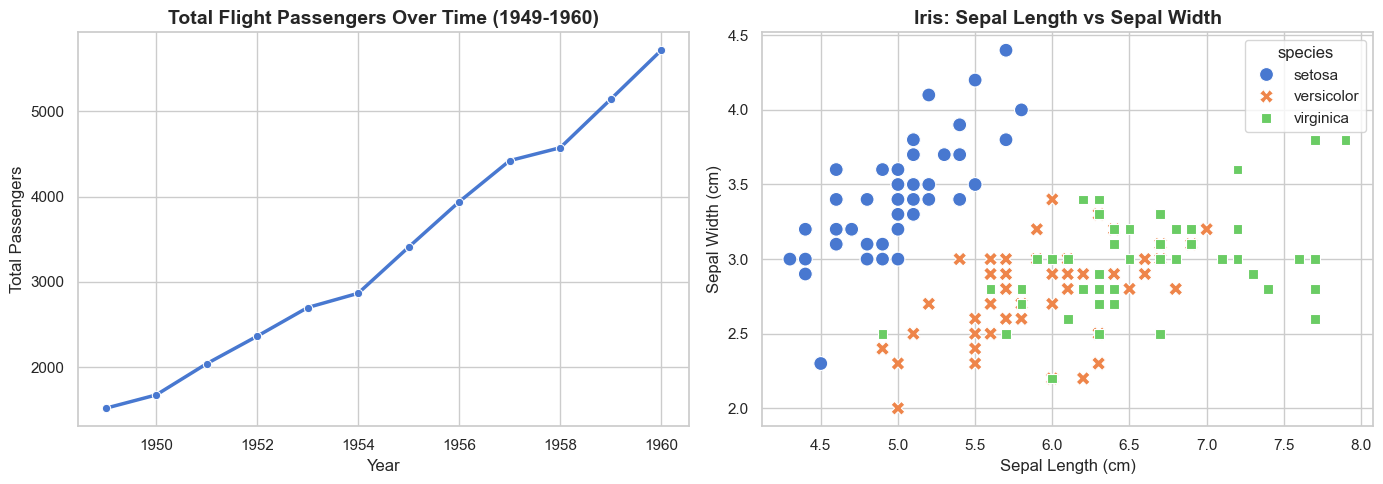

In [2]:
plt.figure(figsize=(14, 5))

# 1. Line Plot (Flights Dataset)
plt.subplot(1, 2, 1)
flights_yearly = flights.groupby('year')['passengers'].sum().reset_index()
sns.lineplot(data=flights_yearly, x='year', y='passengers', marker='o', color='b', linewidth=2.5)
plt.title('Total Flight Passengers Over Time (1949-1960)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Passengers', fontsize=12)

# 2. Scatter Plot (Iris Dataset)
plt.subplot(1, 2, 2)
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width', hue='species', style='species', s=100)
plt.title('Iris: Sepal Length vs Sepal Width', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)

plt.tight_layout()
plt.show()

## Step 3: Categorical & Comparison Plots
Here, we compare different groups within our data. We use a **Bar Chart** to show averages, a **Box Plot** to show distributions and outliers, and a **Violin Plot** to combine distribution density with quartiles.

C:\Users\DELL\AppData\Local\Temp\ipykernel_16596\2186894401.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', ax=axes[0], palette='pastel', ci=None)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16596\2186894401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', ax=axes[0], palette='pastel', ci=None)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16596\2186894401.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=iris, x='species', y='petal_length', ax=axes[2], palette='Set3', inner='quartile')


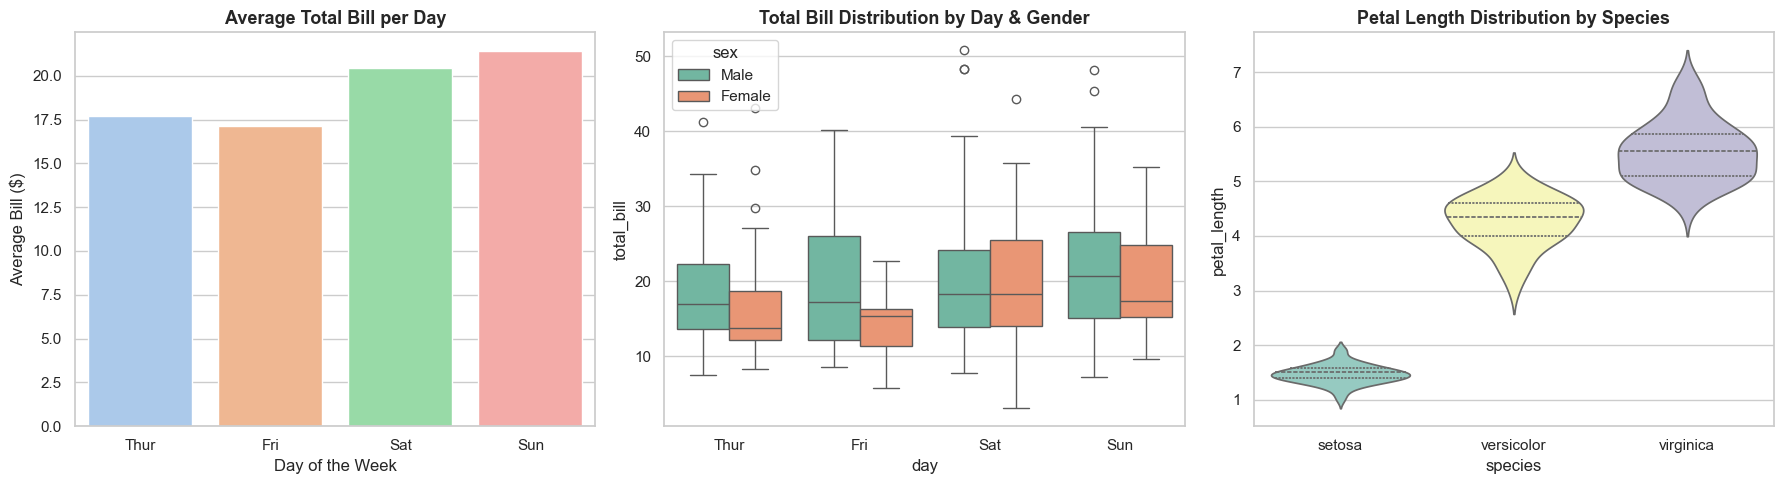

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Chart (Tips Dataset) - Average bill per day
sns.barplot(data=tips, x='day', y='total_bill', ax=axes[0], palette='pastel', ci=None)
axes[0].set_title('Average Total Bill per Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Average Bill ($)')

# 2. Box Plot (Tips Dataset) - Bill distribution and outliers
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1], palette='Set2')
axes[1].set_title('Total Bill Distribution by Day & Gender', fontsize=13, fontweight='bold')

# 3. Violin Plot (Iris Dataset) - Distribution of petal length by species
sns.violinplot(data=iris, x='species', y='petal_length', ax=axes[2], palette='Set3', inner='quartile')
axes[2].set_title('Petal Length Distribution by Species', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 4: Heatmaps & Subplots (OOP API)
Heatmaps are excellent for revealing patterns across two dimensions or showing correlations. Here we use the Object-Oriented (OOP) API of Matplotlib to arrange the heatmaps side by side.

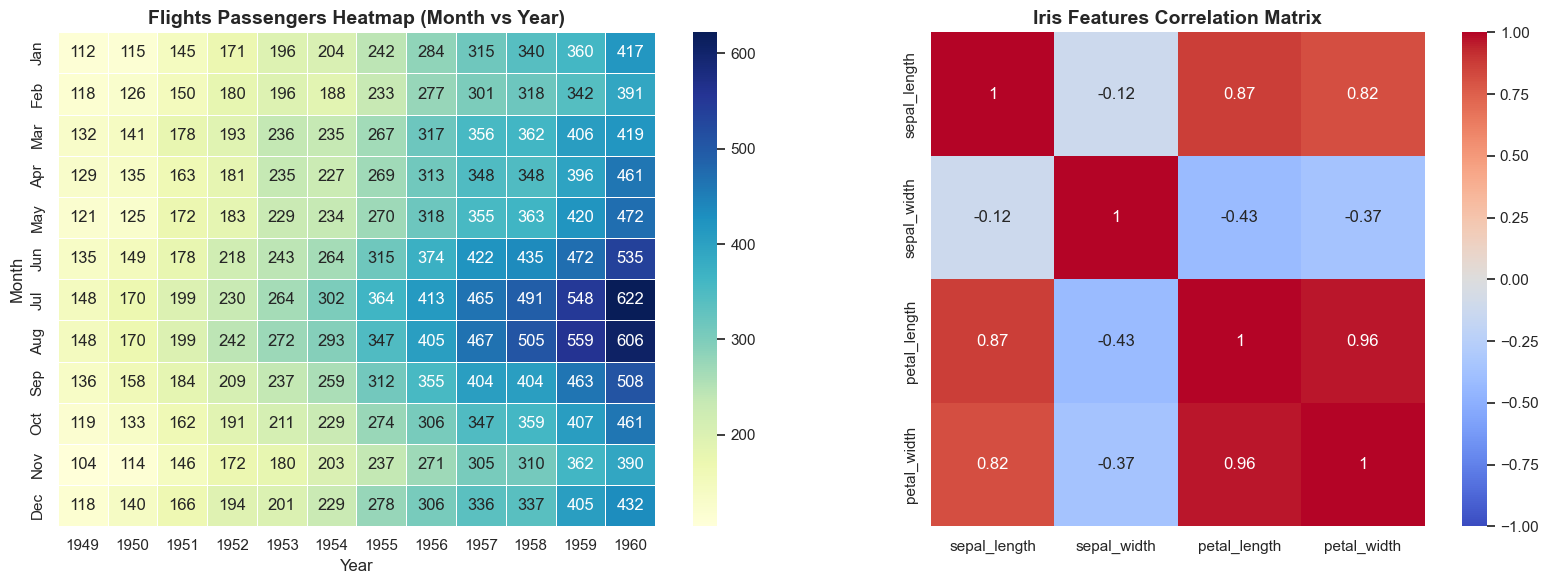

In [4]:
# Pivot the flights dataset for the heatmap
flights_pivot = flights.pivot(index="month", columns="year", values="passengers")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Heatmap (Flights Dataset)
sns.heatmap(flights_pivot, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5, ax=axes[0])
axes[0].set_title('Flights Passengers Heatmap (Month vs Year)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Month')

# 2. Correlation Heatmap (Iris Dataset)
numerical_iris = iris.select_dtypes(include=[np.number])
sns.heatmap(numerical_iris.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title('Iris Features Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 5: Insights & Storytelling
Based on the generated visualiztions, here are the key insights from our data:

1. **Flights Dataset:** Passenger numbers have grown steadily year over year. A strong seasonal pattern exists, with the highest traffic occurring during the summer months (July and August).
2. **Tips Dataset:** Spending habits change based on the day of the week. Customers spend significantly more on average during the weekends. Furthermore, males tend to have a wider range of bill amounts and produce more high-spending outliers.
3. **Iris Dataset:** The *Setosa* species is physically very distinct from *Versicolor* and *Virginica*, primarily marked by its much shorter petal length. There is also a nearly perfect positive correlation (0.96) between a flower's petal length and its petal width.